# <center>十 LangGraph Supervisor 多代理架构应用实战

<div align=center><img src="../pic/lesson09/d.png" width=60%> </div>

&emsp;&emsp;在多代理系统领域的众多框架中，`LangGraph` 是作为**编排代理交互**和**简化复杂工作流程**的强大底层工具而脱颖而出。 一个关键方面是它**能够促进代理主管的角色，代理主管是负责在代理团队之间管理和委派任务的关键实体**。但是，`LangGraph` 是处理多代理工作流程的最佳选择吗？大家将能够通过本节课程的学习和实践得到一个清晰的认知。

&emsp;&emsp;在具体介绍`Supervisor`架构之前，我们先来看一个以`Supervisor`为基础架构构建而成的一个最具代表性的工具：就是微软发布的`Magentic-One`多代理系统。

&emsp;&emsp;`Magentic-One` 是 `Microsoft` 推出的一种**新的通用多代理系统， 同时也是一个基于多智能体 `AI` 的解决方案**。在`Magentic-One`系统中允许多个 `AI` 代理协同工作，每个代理都充当其领域的“专家”去完成特定的功能，例如在软件开发过程中，一个代理会编写文档，另一个代理会审查代码，第三个代理执行质量测试等，通过这种方式实现协同效应，加速流程并改善结果，从而解决高度复杂的问题和任务。

&emsp;&emsp;谈论到具体的功能，`Magentic-One` 此次发布了 5 个默认智能代理，架构组成如下：

- 高级代理 `Orchestrator`：负责高级规划和任务管理的核心组件。它可以指导其他代理，跟踪进度，并在进度停滞时重新规划。
- 四个专业代理支持`Orchestrator`调度，分别是：
  - WebSurfer（网络代理）：管理用于导航和与网页交互的 Web 浏览器。 它可以基于 Chromium 浏览器运行，执行网页搜索、点击以及输入和汇总网页内容。
  - FileSurfer（文件代理）：处理本地文件管理和导航，基于 markdown 的文件预览应用程序读取本地文件。
  - Coder（编码代理）： 专门从事编写和分析代码。
  - ComputerTerminal（PC代理）：提供用于执行程序和安装库的控制台访问权限（即Shell控制台）。

&emsp;&emsp;其五个代理之间的关系如下图所示：

<div align=center><img src="../pic/lesson10/1.png" width=80%></div>

&emsp;&emsp;这是一个具体的用户任务在`Magentic-One `中的执行过程：

<div align=center><img src="../pic/lesson10/2.png" width=80%></div>

&emsp;&emsp;任务需求：`Orchestrator` 收到一个任务，用于在一个图像中提取 `Python` 代码，运行`Python`代码，处理一系列字符串，输出是一个`URL`，其中包含`C++`源代码，需要进一步编译并运行这段`C++`源代码后，返回第三和第五个整数的和。`Orchestrator` 通过以下步骤进行管理和协调完成该复杂任务：
- 第 1 步：`FileSurfer` 代理访问图像，提取 `Python` 代码。
- 第 2 步：`Coder` 代理分析 `Python` 代码。
- 第 3 步：`ComputerTerminal` 执行 `Python` 代码，为 `C++` 代码生成 `URL`。
- 第 4 步： `WebSurfer` 访问 `URL` 并提取 `C++` 代码。
- 第 5 步：另一个 `Coder` 代理分析 `C++` 代码。
- 第 6 步： `ComputerTerminal` 代理执行 `C++` 代码，计算并返回最终结果，完成任务。

&emsp;&emsp;`Magentic-One`的最大特点是可以调整和适应实时变化，使系统能够快速响应新的条件或数据。这种灵活性在客户服务等动态环境中至关重要，因为在这些环境中，查询和要求可能会不断变化。这种覆盖范围是执行需要不同类型分析和响应的复杂流程的关键。而`Supervisor`在大多数情况下，处理的都是类似的工作流编排任务。

&emsp;&emsp;`Magentic-One` 底层是基于`AutoGen`而构建的，接下来我们就来看一下，在`LangGraph` 中 如何通过 `Supervisor` 架构复现这样的复杂工作流。

## 1. Supervisor 架构介绍与基本构建原理 

&emsp;&emsp;正如`Magentic-One`的内部结构一样，`LangGraph` 中的 `Supervisor`充当多代理工作流程中的中央控制器，协调各个代理之间的通信和任务分配。它的工作原理是接收一个代理的输出，解释这些消息，然后相应地指导任务流程。它在`LangGraph` 中基于图结构中的节点实现，允许随着任务的发展或新代理的集成而动态交互和灵活调整工作流程，从而优化流程的有效性和速度。其结构如下图所示：

<div align=center><img src="../pic/lesson10/3.png" width=80%></div>

&emsp;&emsp;实现的思路是：将代理定义为节点，并添加一个 `supervisor` 节点来决定接下来应该调用哪些代理节点。使用条件边根据 `supervisor` 的决策将执行路由到适当的代理节点。我们通过下面的示例来了解其中间的过程：

<div align=center><img src="../pic/lesson10/14.png" width=80%></div>

In [38]:
from IPython.display import Image, display
from langchain_openai import ChatOpenAI

# DeepSeek API 配置
key = "sk-c121e4a7110945ff8f23db283ecdbb2c"
base_url = "https://api.deepseek.com/v1"

llm = ChatOpenAI(model="deepseek-chat", api_key=key, base_url=base_url, temperature=0)


def display_graph(graph, xray=False):
    """Render LangGraph structure; fall back to Mermaid text if mermaid.ink is unreachable."""
    g = graph.get_graph(xray=xray)
    try:
        display(Image(g.draw_mermaid_png(max_retries=3, retry_delay=2.0)))
    except ValueError:
        print(g.draw_mermaid())


In [39]:
import getpass
import os

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="deepseek-chat", api_key=key,base_url=base_url,temperature=0,)


In [3]:
print(llm.invoke("你好，请你介绍一下你自己。").content)

你好呀！很高兴认识你！😊

我是**DeepSeek**，由深度求索公司创造的AI助手。让我给你介绍一下我的“特长”：

✨ **我的能力**：
- **纯文本对话**：我擅长回答各种问题，从日常闲聊到专业知识都可以
- **文件处理**：支持上传图片、PDF、Word、Excel、PPT等文件，我能读取其中的文字信息帮你分析
- **超长上下文**：拥有1M的上下文窗口，可以一次性处理像《三体》三部曲那么大体量的内容
- **联网搜索**：需要最新信息时，你可以手动开启联网功能（在Web/App端操作）

🎁 **我的特点**：
- **完全免费**：没错，不收费！尽管外面谣言四起，但我确实是免费的
- **多平台使用**：网页版、App版都有，App还支持语音输入
- **知识更新**：我的知识截止到2025年5月

📱 **使用方式**：
你可以通过官方应用商店下载App，或者直接访问网页版使用我。

我的风格比较热情细腻，会尽力用温暖的方式回答你的问题。有什么想聊的、想问的，尽管来找我！无论是学习、工作还是生活上的问题，我都乐意帮忙～

那么，今天有什么我可以帮你的吗？💙


&emsp;&emsp;接下来创建代理主管。需要利用`LangGraph`的`StateGraph`、`AgentState`等状态模式来定义`Supervisor`节点的行为和决策逻辑。

In [4]:
from langgraph.graph import StateGraph, MessagesState, START, END

class AgentState(MessagesState):
    next: str

&emsp;&emsp;然后去设置代理主管可以管理的子代理， 添加`FINISH`是为了用来标识 任务是否已经全部完成，可以返回最终的结果了。这就与 `NetWork` 网络代理不同了，`NetWork`网络代理是每一个子代理节点都可以决定是否直接返回`END`，而`supervisor`则是由主管代理节点做一切的决策，这包括是否继续执行，还是结束图的运行状态。

&emsp;&emsp;这里我们定义三个子代理节点，如下：

In [5]:
members = ["chat", "coder", "sqler"]
options = members + ["FINISH"]

In [6]:
options

['chat', 'coder', 'sqler', 'FINISH']

&emsp;&emsp;接下来定义主管节点。主管节点常见的模式是接收状态模式中的相关数据，让大模型根据实时的任务进展自主决定下一步呼叫哪个代理，并通过结构化输出（例如，强制它返回带有“next_agent”字段），以维持图完整的运行状态，直至输出`__end__`，相关代码如下图所示：

In [7]:
from typing import Literal
from typing_extensions import TypedDict
class Router(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH"""

    next: Literal[*options]

&emsp;&emsp;`Literal`是`Python`的`typing`模块中的一个类型，用于定义一个变量的具体值的类型限制。当使用`Literal`时，实际上是在告诉`Python`，变量的值必须是指定的几个值中的一个。而 `next: Literal["chat", "coder", "sqler"]`意味着`next`属性只能赋予三个字符串值之一："chat"、"coder"、"sqler"或"FINISH"， 分别用来表示使用哪一个子代理来执行任务，或者直接通过`END`结束当前的图。

In [8]:
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage

def supervisor(state: AgentState):
    system_prompt = (
        "You are a supervisor tasked with managing a conversation between the"
        f" following workers: {members}.\n\n"
        "Each worker has a specific role:\n"
        "- chat: Responds directly to user inputs using natural language.\n"
        "- coder: Activated for tasks that require mathematical calculations or specific coding needs.\n"
        "- sqler: Used when database queries or explicit SQL generation is needed.\n\n"
        "Given the following user request, respond with the worker to act next."
        " Each worker will perform a task and respond with their results and status."
        " When finished, respond with FINISH."
    )

    messages = [{"role": "system", "content": system_prompt},] + state["messages"]

    # DeepSeek 不支持默认 json_schema，改用 function_calling
    response = llm.with_structured_output(Router, method="function_calling").invoke(messages)

    next_ = response["next"]
    
    if next_ == "FINISH":
        next_ = END
    
    return {"next": next_}       

&emsp;&emsp;接下来依次子代理，每个代理通过`Node`的形式来定义。关键在于：**每个子代理节点在执行完内部逻辑后，在更新全局状态模式的时候，要通过添加`name`= `代理名称` 的方式告诉`supervisor`代理，该信息是哪个子代理返回的数据。要与`members`中的定义保持一致。** 代码如下所示：

In [9]:
def chat(state: AgentState):
    messages = state["messages"][-1]
    model_response = llm.invoke(messages.content)
    final_response = [HumanMessage(content=model_response.content, name="chat")]   # 这里要添加名称
    return {"messages": final_response}

def coder(state: AgentState):
    messages = state["messages"][-1]
    model_response = llm.invoke(messages.content)
    final_response = [HumanMessage(content=model_response.content, name="coder")]   # 这里要添加名称
    return {"messages": final_response}

def sqler(state: AgentState):
    # 返回硬编码的模拟查询结果，不调用 LLM
    dummy_records = """以下是查询到的 3 条模拟销售记录：

1. **销售记录 1**
   - 销售ID: 1001
   - 产品ID: 7
   - 员工ID: 10
   - 客户ID: 36
   - 销售日期: 2024-09-21
   - 数量: 7
   - 金额: 2561.07
   - 折扣: 0.03

2. **销售记录 2**
   - 销售ID: 1002
   - 产品ID: 16
   - 员工ID: 7
   - 客户ID: 15
   - 销售日期: 2024-03-08
   - 数量: 9
   - 金额: 3596.30
   - 折扣: 0.02

3. **销售记录 3**
   - 销售ID: 1003
   - 产品ID: 14
   - 员工ID: 5
   - 客户ID: 12
   - 销售日期: 2024-11-18
   - 数量: 6
   - 金额: 4510.84
   - 折扣: 0.13"""
    final_response = [HumanMessage(content=dummy_records, name="sqler")]
    return {"messages": final_response}

&emsp;&emsp;接下来定义状态图，首先添加所有节点：

In [10]:
builder = StateGraph(AgentState)

# builder.add_edge(START, "supervisor")
builder.add_node("supervisor", supervisor)
builder.add_node("chat", chat)
builder.add_node("coder", coder)
builder.add_node("sqler", sqler)

&emsp;&emsp;然后让每个子代理在完成工作后总是向主管“汇报”，即需要构建它们之间的边。如下所示：

In [11]:
for member in members:
    # 我们希望我们的工人在完成工作后总是向主管“汇报”
    builder.add_edge(member, "supervisor")

&emsp;&emsp;然后在图状态中填充`next`字段，路由到具体的某个节点或者结束图的运行，从来指定如何执行接下来的任务。

In [12]:
# 重新构建图（避免在已 compile 的 builder 上重复加边）
builder = StateGraph(AgentState)
builder.add_node("supervisor", supervisor)
builder.add_node("chat", chat)
builder.add_node("coder", coder)
builder.add_node("sqler", sqler)

for member in members:
    builder.add_edge(member, "supervisor")

builder.add_conditional_edges(
    "supervisor",
    lambda state: state["next"],
    {m: m for m in members} | {END: END},
)
builder.add_edge(START, "supervisor")

graph = builder.compile()


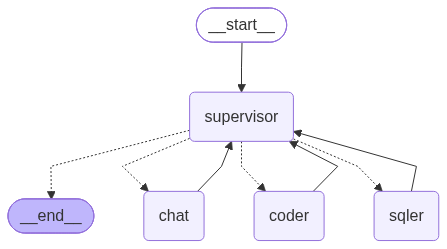

In [13]:
display_graph(graph, xray=True)


&emsp;&emsp;编译完成后，就可以进行问答了，这里我们测试几轮不同的问题类型：

In [141]:
for chunk in graph.stream({"messages": "你好，西瓜是水果吗？"}, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='你好，西瓜是水果吗？', additional_kwargs={}, response_metadata={}, id='722c6ec7-f450-4ff8-964c-a1d8301c97fb')]}
{'messages': [HumanMessage(content='你好，西瓜是水果吗？', additional_kwargs={}, response_metadata={}, id='722c6ec7-f450-4ff8-964c-a1d8301c97fb')], 'next': 'chat'}
{'messages': [HumanMessage(content='你好，西瓜是水果吗？', additional_kwargs={}, response_metadata={}, id='722c6ec7-f450-4ff8-964c-a1d8301c97fb'), HumanMessage(content='你好！是的，西瓜是水果。\n\n从植物学角度来说，西瓜是**葫芦科**植物的果实，属于**浆果**（瓠果），因为它由子房发育而来，内含种子。\n\n不过，在日常生活和烹饪中，西瓜通常被当作**水果**直接生吃，因为它口感清甜多汁。但有趣的是，在某些地方（比如中国南方或东南亚），人们也会把西瓜的果肉或果皮做成**菜肴**（如凉拌西瓜皮、西瓜炒肉），这时它又有点像蔬菜了。\n\n所以，简单回答：**是水果**，但它的用途很灵活。😊', additional_kwargs={}, response_metadata={}, name='chat', id='074373d1-6217-481d-b523-ad3642d5a42e')], 'next': 'chat'}
{'messages': [HumanMessage(content='你好，西瓜是水果吗？', additional_kwargs={}, response_metadata={}, id='722c6ec7-f450-4ff8-964c-a1d8301c97fb'), HumanMessage(content='你好！是的，西瓜是水果。\n\n从植物学角度来说，西瓜是**葫芦科**植物的果实，属于**浆果**（瓠果），

In [142]:
for chunk in graph.stream({"messages": "你好，帮我生成一个helloworld的python代码吗"}, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='你好，帮我生成一个helloworld的python代码吗', additional_kwargs={}, response_metadata={}, id='7ef4724c-b80b-41fe-a6c1-69660e94b40b')]}
{'messages': [HumanMessage(content='你好，帮我生成一个helloworld的python代码吗', additional_kwargs={}, response_metadata={}, id='7ef4724c-b80b-41fe-a6c1-69660e94b40b')], 'next': 'coder'}
{'messages': [HumanMessage(content='你好，帮我生成一个helloworld的python代码吗', additional_kwargs={}, response_metadata={}, id='7ef4724c-b80b-41fe-a6c1-69660e94b40b'), HumanMessage(content='当然可以！这是一个最简单的 Python Hello World 程序：\n\n```python\nprint("Hello, World!")\n```\n\n**运行方法：**\n1. 将代码保存为 `hello.py` 文件\n2. 在终端/命令行中运行：`python hello.py`\n3. 或者直接在 Python 交互式环境中输入这行代码\n\n**输出结果：**\n```\nHello, World!\n```\n\n如果你想要更丰富的版本，这里还有一个带注释的版本：\n\n```python\n# 这是一个简单的 Hello World 程序\ndef main():\n    print("Hello, World!")\n\nif __name__ == "__main__":\n    main()\n```\n\n这个版本使用了函数和主程序入口，是更规范的写法，适合后续扩展。需要我解释代码的某个部分吗？', additional_kwargs={}, response_metadata={}, name='coder', id='cfd0

In [143]:
for chunk in graph.stream({"messages": "我想问问1+1等于几"}, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='我想问问1+1等于几', additional_kwargs={}, response_metadata={}, id='a7906768-f59f-403c-8188-dde58a25f3ae')]}
{'messages': [HumanMessage(content='我想问问1+1等于几', additional_kwargs={}, response_metadata={}, id='a7906768-f59f-403c-8188-dde58a25f3ae')], 'next': 'chat'}
{'messages': [HumanMessage(content='我想问问1+1等于几', additional_kwargs={}, response_metadata={}, id='a7906768-f59f-403c-8188-dde58a25f3ae'), HumanMessage(content='这个问题看起来简单，但其实可以有很多种有趣的回答方式，取决于你从哪个角度来理解：\n\n1. **数学上**：1 + 1 = **2**（这是最标准的答案）。\n2. **逻辑上**：如果你有一个苹果，再给你一个苹果，你就有两个苹果，所以还是 **2**。\n3. **脑筋急转弯**：1 + 1 可能等于 **“王”**（把两个“1”上下叠起来，像汉字“王”的中间部分），或者等于 **“田”**（如果加上边框）。\n4. **二进制里**：1 + 1 = **10**（因为二进制逢二进一）。\n5. **哲学上**：1 + 1 可能等于 **“无限”**（比如一滴水加一滴水，还是一大滴水，但无法精确数出有多少滴）。\n\n如果你是在问最普通的数学答案，那就是 **2**。如果你有其他特别的语境，可以告诉我，我再帮你分析！😊', additional_kwargs={}, response_metadata={}, name='chat', id='fba0b954-f6aa-4f7d-9c51-a3319e3be3c7')], 'next': 'chat'}
{'messages': [HumanMessage(content='我想问问1+1等于几', additional_kw

In [144]:
# all_chunk = []

# for chunk in graph.stream({"messages": "我想查询数据库中 data 表的所有数据，"}, stream_mode="values"):
#     # all_chunk.append(chunk)
#     print(chunk)

In [145]:
# all_chunk[-1]['messages'][-1].content

&emsp;&emsp;如上所示，`supervisor` 的核心构建依赖于状态模式。在此模式中，通过 `next` 字段将主管与各个子代理连接起来。通过前面的示例，我们已经了解了如何构建 `supervisor`。接下来，我们将把这些节点替换成具有实际功能的 `Agent`。

## 2. 案例：基于 Supervisor 架构实现多代理系统

&emsp;&emsp;这里我们使用上节课程中构建的两个子代理数据库管理员`db_agent`和数据分析师`code_agent`，前者据用户的需求操作数据库，提取出核心的数据信息，后者根据`db_agent`传递过来的数据生成对应的代码，并在本地的`Python`解释器进行自动化的数据分析，并生成可视化图表。同时保留大模型交互的`Chat`节点。添加`supervisor`进行统一管理。完整代码如下所示：

<div align=center><img src="../pic/lesson10/3.png" width=80%></div>

- **Step 1. 定义工具**

In [146]:
# 安装到当前 Jupyter 内核对应的 Python 环境
%pip install faker


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [147]:
from sqlalchemy import create_engine, Column, Integer, String, Float, ForeignKey
from sqlalchemy.orm import sessionmaker, declarative_base
from faker import Faker
import random

# 创建基类
Base = declarative_base()

# 定义模型
class SalesData(Base):
    __tablename__ = 'sales_data'
    sales_id = Column(Integer, primary_key=True)
    product_id = Column(Integer, ForeignKey('product_information.product_id'))
    employee_id = Column(Integer)  # 示例简化，未创建员工表
    customer_id = Column(Integer, ForeignKey('customer_information.customer_id'))
    sale_date = Column(String(50))
    quantity = Column(Integer)
    amount = Column(Float)
    discount = Column(Float)

class CustomerInformation(Base):
    __tablename__ = 'customer_information'
    customer_id = Column(Integer, primary_key=True)
    customer_name = Column(String(50))
    contact_info = Column(String(50))
    region = Column(String(50))
    customer_type = Column(String(50))

class ProductInformation(Base):
    __tablename__ = 'product_information'
    product_id = Column(Integer, primary_key=True)
    product_name = Column(String(50))
    category = Column(String(50))
    unit_price = Column(Float)
    stock_level = Column(Integer)

class CompetitorAnalysis(Base):
    __tablename__ = 'competitor_analysis'
    competitor_id = Column(Integer, primary_key=True)
    competitor_name = Column(String(50))
    region = Column(String(50))
    market_share = Column(Float)

# 数据库连接和表创建
# 数据库连接配置（macOS 本地 MySQL）
MYSQL_USER = "root"
MYSQL_PASSWORD = "root"
MYSQL_HOST = "localhost"
MYSQL_DATABASE = "langgraph"

# 先创建数据库（如果不存在）
from sqlalchemy import text
server_engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}/?charset=utf8mb4"
)
with server_engine.connect() as conn:
    conn.execute(text(
        f"CREATE DATABASE IF NOT EXISTS {MYSQL_DATABASE} "
        "CHARACTER SET utf8mb4 COLLATE utf8mb4_unicode_ci"
    ))
    conn.commit()

DATABASE_URI = (
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}/"
    f"{MYSQL_DATABASE}?charset=utf8mb4"
)
engine = create_engine(DATABASE_URI)

Base.metadata.create_all(engine)

Session = sessionmaker(bind=engine)
session = Session()


In [148]:
from pydantic import BaseModel, Field
from langchain_core.tools import tool
from typing import Union, Optional

class AddSaleSchema(BaseModel):
    product_id: int
    employee_id: int
    customer_id: int
    sale_date: str
    quantity: int
    amount: float
    discount: float

class DeleteSaleSchema(BaseModel):
    sales_id: int

class UpdateSaleSchema(BaseModel):
    sales_id: int
    quantity: int
    amount: float

class QuerySalesSchema(BaseModel):
    sales_id: int

# 1. 添加销售数据：
@tool(args_schema=AddSaleSchema)
def add_sale(product_id, employee_id, customer_id, sale_date, quantity, amount, discount):
    """Add sale record to the database."""
    session = Session()
    try:
        new_sale = SalesData(
            product_id=product_id,
            employee_id=employee_id,
            customer_id=customer_id,
            sale_date=sale_date,
            quantity=quantity,
            amount=amount,
            discount=discount
        )
        session.add(new_sale)
        session.commit()
        return {"messages": ["销售记录添加成功。"]}
    except Exception as e:
        return {"messages": [f"添加失败，错误原因：{e}"]}
    finally:
        session.close()

# 2. 删除销售数据
@tool(args_schema=DeleteSaleSchema)
def delete_sale(sales_id):
    """Delete sale record from the database."""
    session = Session()
    try:
        sale_to_delete = session.query(SalesData).filter(SalesData.sales_id == sales_id).first()
        if sale_to_delete:
            session.delete(sale_to_delete)
            session.commit()
            return {"messages": ["销售记录删除成功。"]}
        else:
            return {"messages": [f"未找到销售记录ID：{sales_id}"]}
    except Exception as e:
        return {"messages": [f"删除失败，错误原因：{e}"]}
    finally:
        session.close()

# 3. 修改销售数据
@tool(args_schema=UpdateSaleSchema)
def update_sale(sales_id, quantity, amount):
    """Update sale record in the database."""
    session = Session()
    try:
        sale_to_update = session.query(SalesData).filter(SalesData.sales_id == sales_id).first()
        if sale_to_update:
            sale_to_update.quantity = quantity
            sale_to_update.amount = amount
            session.commit()
            return {"messages": ["销售记录更新成功。"]}
        else:
            return {"messages": [f"未找到销售记录ID：{sales_id}"]}
    except Exception as e:
        return {"messages": [f"更新失败，错误原因：{e}"]}
    finally:
        session.close()

# 4. 查询销售数据
@tool(args_schema=QuerySalesSchema)
def query_sales(sales_id):
    """Query sale record from the database."""
    session = Session()
    try:
        sale_data = session.query(SalesData).filter(SalesData.sales_id == sales_id).first()
        if sale_data:
            return {
                "sales_id": sale_data.sales_id,
                "product_id": sale_data.product_id,
                "employee_id": sale_data.employee_id,
                "customer_id": sale_data.customer_id,
                "sale_date": sale_data.sale_date,
                "quantity": sale_data.quantity,
                "amount": sale_data.amount,
                "discount": sale_data.discount
            }
        else:
            return {"messages": [f"未找到销售记录ID：{sales_id}。"]}
    except Exception as e:
        return {"messages": [f"查询失败，错误原因：{e}"]}
    finally:
        session.close()

In [149]:
# 安装到当前 Jupyter 内核对应的 Python 环境
%pip install langchain_experimental


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [150]:
from typing import Annotated
from langchain_core.tools import tool
from langchain_experimental.utilities import PythonREPL
import json
repl = PythonREPL()

@tool
def python_repl(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user."""
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    result_str = f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"
    return result_str

&emsp;&emsp;使用 `create_react_agent` 构建成两个`ReAct`代理。

In [151]:
from langchain_core.messages import HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import create_react_agent

In [152]:
db_agent = create_react_agent(
    llm, 
    tools=[add_sale, delete_sale, update_sale, query_sales], 
    prompt="You use to perform database operations while should provide accurate data for the code_generator to use"
)

/var/folders/hm/p5x9q0gj1tq37tdyp_pjmqgh0000gn/T/ipykernel_34874/3147679113.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  db_agent = create_react_agent(


In [153]:
code_agent = create_react_agent(
    llm, 
    tools=[python_repl], 
    prompt="Run python code to display diagrams or output execution results"
)

/var/folders/hm/p5x9q0gj1tq37tdyp_pjmqgh0000gn/T/ipykernel_34874/2203434484.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  code_agent = create_react_agent(


&emsp;&emsp;然后分别将两个`ReAct Agent` 构造成节点，并添加代理名称标识。

In [154]:
def db_node(state: AgentState):
    result = db_agent.invoke(state)
    return {
        "messages": [
            HumanMessage(content=result["messages"][-1].content, name="sqler")
        ]
    }


def code_node(state: AgentState):
    result = code_agent.invoke(state)
    return {
        "messages": [HumanMessage(content=result["messages"][-1].content, name="coder")]
    }

&emsp;&emsp;定义父图的状态。

In [155]:
from langgraph.graph import StateGraph, MessagesState, START, END

class AgentState(MessagesState):
    next: str

&emsp;&emsp;然后去设置代理主管可以管理的子代理， 添加`FINISH`是为了用来标识 任务是否已经全部完成，可以返回最终的结果了。

In [156]:
members = ["chat", "coder", "sqler"]
options = members + ["FINISH"]

In [157]:
from typing import Literal
from typing_extensions import TypedDict
class Router(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH"""

    next: Literal[*options]

In [158]:
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage

def supervisor(state: AgentState):
    system_prompt = (
        "You are a supervisor tasked with managing a conversation between the"
        f" following workers: {members}.\n\n"
        "Each worker has a specific role:\n"
        "- chat: Responds directly to user inputs using natural language.\n"
        "Given the following user request, respond with the worker to act next."
        " Each worker will perform a task and respond with their results and status."
        " When finished, respond with FINISH."
    )

    messages = [{"role": "system", "content": system_prompt},] + state["messages"]

    # DeepSeek 不支持默认 json_schema，改用 function_calling
    response = llm.with_structured_output(Router, method="function_calling").invoke(messages)
    next_ = response["next"]
    if next_ == "FINISH":
        next_ = END
    return {"next": next_}

&emsp;&emsp;接下来正常构建`Chat`子代理，通过`Node`的形式来定义。

In [159]:
def chat(state: AgentState):
    messages = state["messages"][-1]
    model_response = llm.invoke(messages.content)
    final_response = [HumanMessage(content=model_response.content, name="chat")]
    return {"messages": final_response}


builder = StateGraph(AgentState)

builder.add_node("supervisor", supervisor)
builder.add_node("chat", chat)
builder.add_node("coder", code_node)
builder.add_node("sqler", db_node)

for member in members:
    # 每个子代理在完成工作后总是向主管“汇报”
    builder.add_edge(member, "supervisor")

builder.add_conditional_edges(
    "supervisor",
    lambda state: state["next"],
    {m: m for m in members} | {END: END},
)

builder.add_edge(START, "supervisor")

graph = builder.compile()

&emsp;&emsp;可视化完整的图结构：

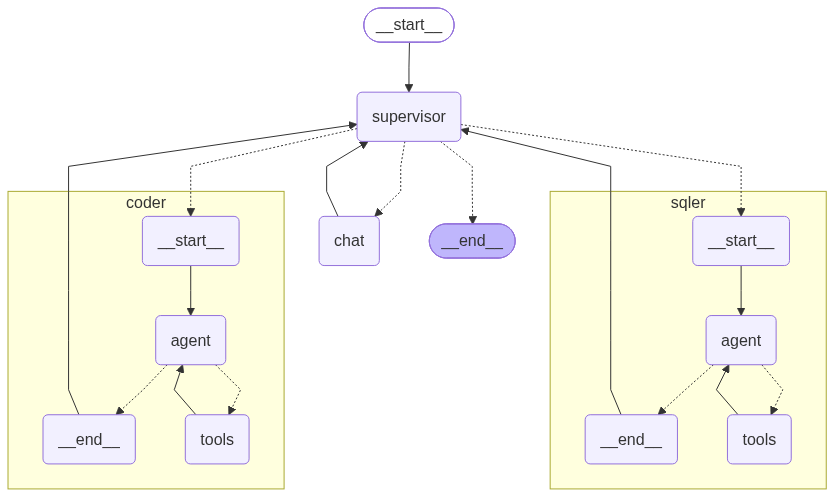

In [160]:
display_graph(graph, xray=True)


&emsp;&emsp;接下来进行问答测试：

In [161]:
for chunk in graph.stream({"messages": "帮我写一段helloworld的python代码"}, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='帮我写一段helloworld的python代码', additional_kwargs={}, response_metadata={}, id='c7613ae8-d20d-4c25-b861-8064d6a07d01')]}
{'messages': [HumanMessage(content='帮我写一段helloworld的python代码', additional_kwargs={}, response_metadata={}, id='c7613ae8-d20d-4c25-b861-8064d6a07d01')], 'next': 'coder'}
{'messages': [HumanMessage(content='帮我写一段helloworld的python代码', additional_kwargs={}, response_metadata={}, id='c7613ae8-d20d-4c25-b861-8064d6a07d01'), HumanMessage(content='好的！上面就是一段最简单的 Python "Hello World" 代码：\n\n```python\nprint("Hello, World!")\n```\n\n**代码说明：**\n- `print()` 是 Python 内置的输出函数，用于在控制台打印内容。\n- 字符串 `"Hello, World!"` 会被输出到屏幕上。\n\n运行结果就是输出：\n```\nHello, World!\n```\n\n这是学习 Python 的第一个经典程序，非常简单易懂。如果你还想了解其他变体（比如用变量、函数等），随时告诉我！', additional_kwargs={}, response_metadata={}, name='coder', id='044f8b80-f754-465a-bdc7-06b0bb5c851f')], 'next': 'coder'}
{'messages': [HumanMessage(content='帮我写一段helloworld的python代码', additional_kwargs={}, response_metadata={}, id='c76

In [ ]:
for chunk in graph.stream({"messages": "帮我根据前10名的 销售记录id，生成对应的销售额柱状图"}, stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='帮我根据前10名的 销售记录id，生成对应的销售额柱状图', additional_kwargs={}, response_metadata={}, id='09ca19ed-6286-4218-b0b0-3dca86b282fc')]}
{'messages': [HumanMessage(content='帮我根据前10名的 销售记录id，生成对应的销售额柱状图', additional_kwargs={}, response_metadata={}, id='09ca19ed-6286-4218-b0b0-3dca86b282fc')], 'next': 'sqler'}
{'messages': [HumanMessage(content='帮我根据前10名的 销售记录id，生成对应的销售额柱状图', additional_kwargs={}, response_metadata={}, id='09ca19ed-6286-4218-b0b0-3dca86b282fc'), HumanMessage(content='I\'ve checked sales records with IDs 1-30 and none of them exist in the database. The database appears to be empty of sales records.\n\nAdditionally, when I tried to add new sales records, they all failed due to a **foreign key constraint** on `product_id` - the product IDs I used (101-110) don\'t exist in the `product_information` table.\n\nHere\'s a summary of the situation:\n\n## 当前情况说明\n\n**问题：无法生成前10名销售额柱状图**\n\n我遇到了以下问题：\n\n1. **数据库中没有销售记录**：我查询了销售记录ID 1-30，均返回"未找到销售记录"，说明 `sales_dat

In [ ]:
for chunk in graph.stream({"messages": "你好，什么是机器学习？"}, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

In [ ]:
for chunk in graph.stream({"messages": "帮我删除 第 33条销售数据"}, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

&emsp;&emsp;`LangGraph`中构建`supervisor`很高效，代理监督和 `StateGraph`的构架方式可以极大简化工作流程、优化任务分配并增强多代理系统内的协作。但也存在一些问题。比如大家在后续尝试的过程中会发现经常可以看到主管不断地一次又一次地将一个代理的输出发送给自己，开始自言自语，这就会导致更高的运行时间和更高的`Token`消耗，同时，在决策方向选择其他代理人而不是首选代理人，从而导致幻觉。这些都是我们在自己应用的时候，结合具体的业务逻辑，以及所使用的大模型的原生能力进行针对性的调整。

&emsp;&emsp;而至于`supervisor`的变体 `Supervisor (tool-calling)` 和 `Hierarchical`，不过是以不同的方式对`supervisor`进行嵌套应用，可以更模块化、规范化代理的处理构建更庞大的`Agent`集群，但带来的问题同时也是更高的`Token`和更缓慢的处理速度，就目前` AI Agent`的发展阶段来说，所应用的范畴还是较少。如果感兴趣可以在如下官网进一步了解，课程中不做重复的说明。[LangGraph Hierarchical Agent](https://langchain-ai.github.io/langgraph/concepts/multi_agent/#hierarchical)

## 3. 案例：Multi-Agent实现混合多知识库检索

<div align=center><img src="../pic/lesson10/15.png" width=80%></div>

### 3.1  GraphRAG 基本介绍

&emsp;&emsp;检索增强生成（Retrieval-Augmented Generation）技术是一种结合了检索和生成两个阶段的自然语言处理技术，它由 `Facebook AI` 团队在 2020 年提出。这种方法的核心思想是利用大规模的预训练语言模型生成技术，并结合信息检索的策略，以改善回答的准确性和相关性。

&emsp;&emsp;这种传统的 `RAG` 通过 `Text2Vec` 检索的方式通过将生成的响应与现实世界的数据联系起来来减少幻觉，但**准确回答复杂问题是另一回事**。这在于每个文本嵌入都表示非结构化数据集中的一个特定块，通过最近邻算法搜索查找表示在语义上与传入用户查询相似的块的嵌入，这也意味着搜索是语义性的，但仍然高度具体。因此，候选块的质量在很大程度上取决于查询质量。就像翻阅一本食谱书一样。使用关键字搜索“炒鸡蛋”或“西红柿鸡蛋面”并找到说明，它速度很快，对于简单的问题非常有效。但是，如果你对这些菜肴背后的文化背景或是想知道为什么某些成分能够协同作用增加风味感兴趣，仅仅关键字搜索可能就显得力不从心。例如，西红柿和鸡蛋为何能搭配得如此完美？

&emsp;&emsp;同时，对于已经熟悉 `RAG` 的小伙伴来说，可能遇到了与我相同的头痛问题：
- 上下文在文本块之间丢失
- 随着检索到的文档的增长，性能会下降
- 整合外部知识感觉就像蒙着眼睛试图解开魔方

&emsp;&emsp;**欢迎来到 GraphRAG ！**

&emsp;&emsp;传统`RAG`系统在负责合成来自各种来源的信息或理解数据集中的总体主题时却很困难。例如，如果询问传统`RAG` 系统：“根据该研究数据集，全球气温变暖的主要原因是什么？”，它很难提供全面的答案，因为与气候相关的不同信息的分散在整个数据集中，而语义检索的方式没有办法跨整个数据集去做全局检索。这样的需求凸显了对 `RAG` 更加结构化和智能的方法的需求。这就是 GraphRAG（Graph Retrieval-Augmented Generation）派上用场的地方，它的核心作用是**提高大模型的模型通过利用结构化知识图谱提供精确且上下文丰富的答案的能力**。

<div align=center><img src="../pic/lesson10/4.png" width=80%></div>

<div align=center><img src="../pic/lesson10/5.png" width=80%></div>

<div align=center><img src="../pic/lesson10/6.png" width=80%></div>

&emsp;&emsp;`GraphRAG`通过利用大模型从原始文本数据中提取知识图谱来满足跨上下文检索的需求。该知识图将信息表示为互连实体和关系的网络，与简单的文本片段相比，提供了更丰富的数据表示。这种结构化表示使 `GraphRAG` 能够擅长回答需要推理和连接不同信息的复杂问题。

&emsp;&emsp;在本案例中，我们将探讨和实践如何使用 `Neo4j` 和 `LangChain` 来实现 GraphRAG。 `Neo4j` 是一种流行的图形数据库，用于以类似图形的结构表示数据，其中实体是节点，实体之间的关系是边。当与 `LangChain` 集成时，`Neo4j` 就变成了使用结构化图数据执行`RAG` 的强大工具。`Neo4j`的使用主要有两种方式，一种是本地安装，另一种则是可以使用云服务，这里我们选择使用`Neo4j Aura`，它提供了一个免费的实例可以供我们使用。

### 3.2. 配置 Neo4j 图数据库实例

&emsp;&emsp;首先，登录该地址注册免费账户：https://console.neo4j.io/?product=aura-db&tenant=2afe251b-59ae-5517-9598-84fc5d57b0b5

<div align=center><img src="../pic/lesson10/7.png" width=60%></div>

&emsp;&emsp;创建`Neo4j`实例：

<div align=center><img src="../pic/lesson10/8.png" width=60%></div>

<div align=center><img src="../pic/lesson10/9.png" width=60%></div>

&emsp;&emsp;这里可以选择一个免费的实例：

<div align=center><img src="../pic/lesson10/10.png" width=60%></div>

&emsp;&emsp;创建的时候记得保存密码，将用于后续的连接。

<div align=center><img src="../pic/lesson10/11.png" width=60%></div>

&emsp;&emsp;等待创建完成。

<div align=center><img src="../pic/lesson10/12.png" width=60%></div>

&emsp;&emsp;创建完成后，将会生成一个远程连接的`Uri`。

<div align=center><img src="../pic/lesson10/13.png" width=60%></div>

### 3.3 创建图索引及构建 GraphRAG Agent

&emsp;&emsp;在将数据 引入`Neo4j`图数据库之前，一般来说我们会将数据（例如 .txt 或 .csv 文件）拆分为可管理的块。可以使用`LangChain`框架的 `TextLoader` 和 `RecursiveCharacterTextSplitter` 来完成。用于演示目的，我们此处不进行分块，将完整的文档作为一个 `TextUnit`进行图属性的提取。

In [40]:
# 打开文件，并赋予读取模式 'r'
with open('../doc/company.txt', 'r', encoding="utf-8") as file:
    # 读取文件的全部内容
    content = file.read()
    print(content)

小米科技有限责任公司（小米）：

产品创新： 小米持续推动技术创新，尤其在智能手机摄像技术和快充技术方面取得突破。例如，小米推出了首款1亿像素手机摄像头，大幅提升了手机摄影的质量。此外，小米还开发了120W超快闪充技术，可以在15分钟内为手机充满电，这一技术在行业中引起了广泛关注。

市场扩展： 小米积极开拓国际市场，特别是在印度、东南亚和欧洲市场表现突出。小米通过与当地电信运营商合作，推广其智能手机和生态链产品，迅速在当地市场建立了品牌影响力。例如，在印度，小米通过在线和离线双渠道销售策略迅速占领了市场，成为智能手机市场的领导者之一。

企业社会责任： 小米非常注重其企业社会责任，积极参与社会公益活动。小米设立了多个基金会，支持教育和科技创新项目，例如通过小米基金会资助贫困地区的学校建设和提供科技设备，帮助提升教育质量。此外，小米还在产品设计中采用环保材料，推广环保理念。

品牌合作与宣传： 小米在品牌合作方面表现活跃，与世界各大品牌如Adobe、微软等进行合作，共同开发更多功能强大的手机应用和服务。此外，小米通过赞助体育赛事和文化活动等多种方式提升品牌知名度，如成为欧洲足球俱乐部的官方赞助商。




华为技术有限公司（华为）：

技术研发和创新： 华为在全球设有20多个研发中心，不断推动通信技术的创新和前瞻性研究。华为的研发重点包括5G网络技术、云计算、大数据解决方案以及人工智能。华为的鸿蒙操作系统（HarmonyOS）是一个多设备分布式操作系统，旨在提供跨平台的无缝体验，这标志着华为在自主知识产权方面迈出了重要步伐。

全球市场战略： 华为致力于在全球市场中扩大其影响力，尤其在欧洲、亚洲和非洲。尽管面临国际贸易限制，华为通过与地方政府和企业的紧密合作，成功部署了多个5G网络项目，并通过提供定制化的ICT解决方案来巩固其市场地位。华为还通过举办技术峰会和参与国际通信展览会，如巴塞尔世界移动通信大会，增强其品牌可见度。

合作与伙伴关系： 华为与全球多家顶尖大学和研究机构建立了合作关系，共同进行技术研究和开发。例如，华为与英国的剑桥大学合作开发下一代光通信技术。此外，华为在全球范围内与多家IT和电信企业建立了战略合作伙伴关系，共同推动通信技术的发展和应用。

社会责任与企业文化： 华为注重企业社会责任，积极参与全球的教育和健康项目。例如，华为“未来种子计划”旨在

&emsp;&emsp;转化成`Document`对象。

In [41]:
from langchain_core.documents import Document

documents = [Document(page_content=content)]

In [42]:
documents

[Document(metadata={}, page_content='小米科技有限责任公司（小米）：\n\n产品创新： 小米持续推动技术创新，尤其在智能手机摄像技术和快充技术方面取得突破。例如，小米推出了首款1亿像素手机摄像头，大幅提升了手机摄影的质量。此外，小米还开发了120W超快闪充技术，可以在15分钟内为手机充满电，这一技术在行业中引起了广泛关注。\n\n市场扩展： 小米积极开拓国际市场，特别是在印度、东南亚和欧洲市场表现突出。小米通过与当地电信运营商合作，推广其智能手机和生态链产品，迅速在当地市场建立了品牌影响力。例如，在印度，小米通过在线和离线双渠道销售策略迅速占领了市场，成为智能手机市场的领导者之一。\n\n企业社会责任： 小米非常注重其企业社会责任，积极参与社会公益活动。小米设立了多个基金会，支持教育和科技创新项目，例如通过小米基金会资助贫困地区的学校建设和提供科技设备，帮助提升教育质量。此外，小米还在产品设计中采用环保材料，推广环保理念。\n\n品牌合作与宣传： 小米在品牌合作方面表现活跃，与世界各大品牌如Adobe、微软等进行合作，共同开发更多功能强大的手机应用和服务。此外，小米通过赞助体育赛事和文化活动等多种方式提升品牌知名度，如成为欧洲足球俱乐部的官方赞助商。\n\n\n\n\n华为技术有限公司（华为）：\n\n技术研发和创新： 华为在全球设有20多个研发中心，不断推动通信技术的创新和前瞻性研究。华为的研发重点包括5G网络技术、云计算、大数据解决方案以及人工智能。华为的鸿蒙操作系统（HarmonyOS）是一个多设备分布式操作系统，旨在提供跨平台的无缝体验，这标志着华为在自主知识产权方面迈出了重要步伐。\n\n全球市场战略： 华为致力于在全球市场中扩大其影响力，尤其在欧洲、亚洲和非洲。尽管面临国际贸易限制，华为通过与地方政府和企业的紧密合作，成功部署了多个5G网络项目，并通过提供定制化的ICT解决方案来巩固其市场地位。华为还通过举办技术峰会和参与国际通信展览会，如巴塞尔世界移动通信大会，增强其品牌可见度。\n\n合作与伙伴关系： 华为与全球多家顶尖大学和研究机构建立了合作关系，共同进行技术研究和开发。例如，华为与英国的剑桥大学合作开发下一代光通信技术。此外，华为在全球范围内与多家IT和电信企业建立了战略合作伙伴关系，共同推动通信技术的发展和应

&emsp;&emsp;准备好数据后，我们可以使用 `langchain_experimental.graph_transformers` 中的 `LLMGraphTransformer` 将其摄取到 `Neo4j` 中。该工具会自动将文档转换为图格式。`LLMGraphTransformer` 能够以两种完全独立的模式运行：
- Tool-Based 模式（默认）：当使用的大模型支持结构化输出或函数调用时，该模式利用内置的`with_structured_output`来使用工具。工具规范定义了输出格式，确保以结构化、预定义的方式提取实体和关系。
- 基于提示的模式（回退）：在使用的大模型不支持工具或函数调用的情况下， 该转换器回退到纯粹提示驱动的方法。该模式使用`few-shot`提示来定义输出格式，指导大模型以基于文本的方式提取实体和关系。然后通过自定义函数解析结果，该函数将大模型的输出转换为 `JSON` 格式。该 `JSON` 用于填充节点和关系。

In [43]:
! pip install neo4j


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [44]:
# GraphRAG Setup
from langchain_community.graphs import Neo4jGraph
from langchain_experimental.graph_transformers import LLMGraphTransformer
from langchain_core.documents import Document
from langchain_openai import ChatOpenAI

# 创建图数据库示例
graph = Neo4jGraph(
    url="neo4j+ssc://06621ec6.databases.neo4j.io",  # ssc = skip strict cert check
    username="06621ec6",
    password="EHj9FIgwiOiaYUXkwh1S2j_bz8rZAEg4D7WcXqiWgkY",
    database="06621ec6", 
)

graph_llm = ChatOpenAI(temperature=0, model_name="deepseek-chat" ,api_key=key,base_url=base_url)


Unable to retrieve routing information


ValueError: Could not connect to Neo4j database. Please ensure that the url is correct

&emsp;&emsp;使用`convert_to_graph_documents`函数处理文档，进行实体和关系的提取。可以自定义，当`allowed_nodes`和`allowed_relationships`不手动填写的时候，它会自动判断并进行提取。

In [ ]:
%pip install json-repair

In [45]:
# DeepSeek 不支持 json_schema：必须 ignore_tool_usage=True，且不要再覆盖成默认配置
%pip install json-repair -q

graph_transformer = LLMGraphTransformer(
    llm=graph_llm,
    allowed_nodes=["公司", "产品", "技术", "市场", "活动", "合作伙伴"],
    allowed_relationships=["推出", "参与", "合作", "位于", "开发"],
    ignore_tool_usage=True,  # 绕过 with_structured_output，避免 DeepSeek 400
)

graph_documents = graph_transformer.convert_to_graph_documents(documents)

graph.add_graph_documents(graph_documents)

print(f"Graph documents: {len(graph_documents)}")
print(f"Nodes from 1st graph doc:{graph_documents[0].nodes}")
print(f"Relationships from 1st graph doc:{graph_documents[0].relationships}")


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


[#DC05]  _: <CONNECTION> error: Failed to read from defunct connection ResolvedIPv4Address(('198.18.0.187', 7687)) (ResolvedIPv4Address(('198.18.0.187', 7687))): SSLError(1, '[SSL: DECRYPTION_FAILED_OR_BAD_RECORD_MAC] decryption failed or bad record mac (_ssl.c:2580)')
Unable to retrieve routing information
Transaction failed and will be retried in 0.9728233763178169s (Unable to retrieve routing information)
Unable to retrieve routing information
Transaction failed and will be retried in 1.6233609957450423s (Unable to retrieve routing information)
[#DC19]  _: <CONNECTION> error: Failed to read from defunct connection IPv4Address(('p-mt-3b814dd7cab7-10-0101.production-orch-0068.neo4j.io', 7687)) (ResolvedIPv4Address(('198.18.0.189', 7687))): SSLError(1, '[SSL: DECRYPTION_FAILED_OR_BAD_RECORD_MAC] decryption failed or bad record mac (_ssl.c:2580)')
Transaction failed and will be retried in 4.132728197358859s (Failed to read from defunct connection IPv4Address(('p-mt-3b814dd7cab7-10-0101.

Graph documents: 1
Nodes from 1st graph doc:[Node(id='Adobe', type='合作伙伴', properties={}), Node(id='谷歌', type='合作伙伴', properties={}), Node(id='地方政府', type='合作伙伴', properties={}), Node(id='IT企业', type='合作伙伴', properties={}), Node(id='社会公益活动', type='活动', properties={}), Node(id='小米科技有限责任公司', type='公司', properties={}), Node(id='1亿像素手机摄像头', type='产品', properties={}), Node(id='未来种子计划', type='活动', properties={}), Node(id='企业', type='合作伙伴', properties={}), Node(id='MacBook', type='产品', properties={}), Node(id='英特尔', type='合作伙伴', properties={}), Node(id='剑桥大学', type='合作伙伴', properties={}), Node(id='华为技术有限公司', type='公司', properties={}), Node(id='120W超快闪充技术', type='技术', properties={}), Node(id='微软', type='合作伙伴', properties={}), Node(id='技术峰会', type='活动', properties={}), Node(id='体育赛事', type='活动', properties={}), Node(id='音乐制作公司', type='合作伙伴', properties={}), Node(id='苹果公司', type='公司', properties={}), Node(id='当地电信运营商', type='合作伙伴', properties={}), Node(id='鸿蒙操作系统', type='产品', properties={}), Nod

&emsp;&emsp;进入后即可查看到生成的知识图谱：

<div align=center><img src="../pic/lesson10/16.png" width=60%></div>

&emsp;&emsp;`Neo4j` 通过利用图算法（例如 PageRank 或社区检测）来检索子图。这些算法识别相关实体的集群，`LangChain` 从 `Neo4j` 检索子图并通过大模型生成响应，这里可以使用到`GraphCypherQAChain`工具，代码如下：

In [51]:
# from langchain.chains import GraphCypherQAChain
from langchain_community.chains.graph_qa.cypher import GraphCypherQAChain

llm =ChatOpenAI(temperature=0, model_name="deepseek-chat" ,api_key=key,base_url=base_url)

cypher_chain = GraphCypherQAChain.from_llm(
    graph=graph,
    cypher_llm=llm,
    qa_llm=llm,
    validate_cypher=True, # Validate relationship directions
    verbose=True,
    allow_dangerous_requests=True
)
cypher_chain.invoke("数据库里有哪些数据？")




> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (n) RETURN n LIMIT 25
Full Context:
[{'n': {'id': 'Adobe'}}, {'n': {'id': '谷歌'}}, {'n': {'id': '地方政府'}}, {'n': {'id': 'IT企业'}}, {'n': {'id': '社会公益活动'}}, {'n': {'id': '小米科技有限责任公司'}}, {'n': {'id': '1亿像素手机摄像头'}}, {'n': {'id': '未来种子计划'}}, {'n': {'id': '企业'}}, {'n': {'id': 'MacBook'}}]

> Finished chain.


{'query': '数据库里有哪些数据？',
 'result': '数据库里包含以下数据：Adobe、谷歌、地方政府、IT企业、社会公益活动、小米科技有限责任公司、1亿像素手机摄像头、未来种子计划、企业、MacBook。'}

In [52]:
llm =ChatOpenAI(temperature=0, model_name="deepseek-chat" ,api_key=key,base_url=base_url)

cypher_chain = GraphCypherQAChain.from_llm(
    graph=graph,
    cypher_llm=llm,
    qa_llm=llm,
    validate_cypher=True, # Validate relationship directions
    verbose=True,
    allow_dangerous_requests=True
)
cypher_chain.invoke("华为技术有限公司与哪些教育机构建立了合作？")




> Entering new GraphCypherQAChain chain...
Generated Cypher:

Full Context:
[]

> Finished chain.


{'query': '华为技术有限公司与哪些教育机构建立了合作？',
 'result': '抱歉，我目前没有掌握华为技术有限公司与教育机构合作的具体信息。如果您能提供更多相关细节，我很乐意帮您整理成清晰的回答。'}

In [53]:
llm =ChatOpenAI(temperature=0, model_name="deepseek-chat" ,api_key=key,base_url=base_url)

cypher_chain = GraphCypherQAChain.from_llm(
    graph=graph,
    cypher_llm=llm,
    qa_llm=llm,
    validate_cypher=True, # Validate relationship directions
    verbose=True,
    allow_dangerous_requests=True
)
cypher_chain.invoke("都有哪些公司在我的数据库中？")




> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (n:Company) RETURN n


Received notification from DBMS server: <GqlStatusObject gql_status='01N50', status_description='warn: label does not exist. The label `Company` does not exist in database `06621ec6`. Verify that the spelling is correct.', position=<SummaryInputPosition line=1, column=10, offset=9>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 9, 'line': 1, 'column': 10}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH (n:Company) RETURN n'


Full Context:
[]

> Finished chain.


{'query': '都有哪些公司在我的数据库中？',
 'result': '抱歉，我目前没有找到关于您数据库中公司列表的相关信息。如果您能提供更多细节，我会尽力帮助您。'}

In [54]:
cypher_chain = GraphCypherQAChain.from_llm(
    graph=graph,
    cypher_llm=llm,
    qa_llm=llm,
    validate_cypher=True,
    allow_dangerous_requests=True
)
response = cypher_chain.invoke("都有哪些公司在我的数据库中？")

Received notification from DBMS server: <GqlStatusObject gql_status='01N50', status_description='warn: label does not exist. The label `Company` does not exist in database `06621ec6`. Verify that the spelling is correct.', position=<SummaryInputPosition line=1, column=10, offset=9>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 9, 'line': 1, 'column': 10}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH (n:Company) RETURN n'


In [55]:
response["result"]

'抱歉，我目前没有关于您数据库中公司列表的信息。如果您能提供具体的数据或查询范围，我可以帮您整理和呈现。'

&emsp;&emsp;其中的内部原理如下所示：
```json
cypher_prompt = PromptTemplate(
    template="""You are an expert at generating Cypher queries for Neo4j.
    Use the following schema to generate a Cypher query that answers the given question.
    Make the query flexible by using case-insensitive matching and partial string matching where appropriate.
    Focus on searching paper titles as they contain the most relevant information.
    
    Schema:
    {schema}
    
    Question: {question}
    
    Cypher Query:""",
    input_variables=["schema", "question"],
)

# QA prompt
qa_prompt = PromptTemplate(
    template="""You are an assistant for question-answering tasks. 
    Use the following Cypher query results to answer the question. If you don't know the answer, just say that you don't know. 
    Use three sentences maximum and keep the answer concise. If topic information is not available, focus on the paper titles.
    
    Question: {question} 
    Cypher Query: {query}
    Query Results: {context} 
    
    Answer:""",
    input_variables=["question", "query", "context"],
)
```

&emsp;&emsp;我们封装成多代理系统中的一个工具。如下代码所示：

In [117]:
from langgraph.graph import StateGraph, MessagesState, START, END

class AgentState(MessagesState):
    next: str

In [118]:
def graph_kg(state: AgentState):
    messages = state["messages"][-1]
    cypher_chain = GraphCypherQAChain.from_llm(
    graph=graph,
    cypher_llm=llm,
    qa_llm=llm,
    validate_cypher=True,
    allow_dangerous_requests=True
    )
    response = cypher_chain.invoke(messages.content) 
    final_response = [HumanMessage(content=response["result"], name="graph_kg")]   # 这里要添加名称
    return {"messages": final_response}

## 3.4 创建传统 RAG Agent

In [119]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

chunk_size = 250
chunk_overlap = 30
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=chunk_size, chunk_overlap=chunk_overlap
)

# Split
splits = text_splitter.split_documents(documents)
splits

[Document(metadata={'id': '7d1a58e8a810b48adbe5e0ac09de2cb9'}, page_content='小米科技有限责任公司（小米）：\n\n产品创新： 小米持续推动技术创新，尤其在智能手机摄像技术和快充技术方面取得突破。例如，小米推出了首款1亿像素手机摄像头，大幅提升了手机摄影的质量。此外，小米还开发了120W超快闪充技术，可以在15分钟内为手机充满电，这一技术在行业中引起了广泛关注。'),
 Document(metadata={'id': '7d1a58e8a810b48adbe5e0ac09de2cb9'}, page_content='市场扩展： 小米积极开拓国际市场，特别是在印度、东南亚和欧洲市场表现突出。小米通过与当地电信运营商合作，推广其智能手机和生态链产品，迅速在当地市场建立了品牌影响力。例如，在印度，小米通过在线和离线双渠道销售策略迅速占领了市场，成为智能手机市场的领导者之一。'),
 Document(metadata={'id': '7d1a58e8a810b48adbe5e0ac09de2cb9'}, page_content='企业社会责任： 小米非常注重其企业社会责任，积极参与社会公益活动。小米设立了多个基金会，支持教育和科技创新项目，例如通过小米基金会资助贫困地区的学校建设和提供科技设备，帮助提升教育质量。此外，小米还在产品设计中采用环保材料，推广环保理念。\n\n品牌合作与宣传： 小米在品牌合作方面表现活跃，与世界各大品牌如Adobe、微软等进行合作，共同开发更多功能强大的手机应用和服务。此外，小米通过赞助体育赛事和文化活动等多种方式提升品牌知名度，如成为欧洲足球俱乐部的官方赞助商。'),
 Document(metadata={'id': '7d1a58e8a810b48adbe5e0ac09de2cb9'}, page_content='华为技术有限公司（华为）：\n\n技术研发和创新： 华为在全球设有20多个研发中心，不断推动通信技术的创新和前瞻性研究。华为的研发重点包括5G网络技术、云计算、大数据解决方案以及人工智能。华为的鸿蒙操作系统（HarmonyOS）是一个多设备分布式操作系统，旨在提供跨平台的无缝体验，这标志着华为在自主知识产权方面迈出了重要步伐。'),
 Docum

&emsp;&emsp;这里我们同样使用免费的在线`milvus`实例，地址如下：https://cloud.zilliz.com/login?redirect=/orgs ， 先注册登录：

<div align=center><img src="../pic/lesson10/a.png" width=60%></div>

<div align=center><img src="../pic/lesson10/b.png" width=60%></div>

&emsp;&emsp;然后创建索引：

<div align=center><img src="../pic/lesson10/c.png" width=60%></div>

&emsp;&emsp;选择免费实例：

<div align=center><img src="../pic/lesson10/d.png" width=60%></div>

&emsp;&emsp;注意：这里需要保存好用户名和密码，用于接下来的远程连接。

<div align=center><img src="../pic/lesson10/e.png" width=60%></div>

&emsp;&emsp;等待创建完成后，注意关注如下信息：

<div align=center><img src="../pic/lesson10/f.png" width=60%></div>

In [129]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(
    model="text-embedding-3-large",api_key=key,base_url=base_url
)

&emsp;&emsp;通过如下代码构建向量索引，并存储到云端的`Milvus`向量数据库中。

In [122]:
! pip install langchain_milvus

Looking in indexes: http://mirrors.aliyun.com/pypi/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 2.6 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 11.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.7/53.7 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 MB 9.3 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: grpcio
    Found existing installation: grpcio 1.68.0
    Uninstalling grpcio-1.68.0:
      Successfully uninstalled grpcio-1.68.0


In [132]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_milvus import Milvus

#
# https://in03-05067544a04d5be.serverless.gcp-us-west1.cloud.zilliz.com
# https://in03-05067544a04d5be.serverless.gcp-us-west1.cloud.zilliz.com

# Add to Milvus
vectorstore = Milvus.from_documents(
    documents=splits,
    collection_name="company_milvus",
    embedding=embeddings,
    connection_args={
        "uri": "https://in03-05067544a04d5be.serverless.gcp-us-west1.cloud.zilliz.com",
        "user": "db_05067544a04d5be",
        "password": "Au7>]C8,JAef<%2W",
    }
)

&emsp;&emsp;同时可以登录网页端进行确认：

<div align=center><img src="../pic/lesson10/g.png" width=60%></div>

In [133]:
from langchain.prompts import PromptTemplate
from langchain import hub
from langchain_core.output_parsers import StrOutputParser

# 提示
prompt = PromptTemplate(
    template="""You are an assistant for question-answering tasks. 
    Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. 
    Use three sentences maximum and keep the answer concise:
    Question: {question} 
    Context: {context} 
    Answer: 
    """,
    input_variables=["question", "document"],
)

# 构建传统的RAG Chain
rag_chain = prompt | graph_llm | StrOutputParser()

# 运行
question = "我的知识库中都有哪些公司信息"

# 构建检索器
retriever = vectorstore.as_retriever(search_kwargs={"k": 1})

# 执行检索
docs = retriever.invoke("question")

docs

[Document(metadata={'pk': 455320723018648932, 'id': '7d1a58e8a810b48adbe5e0ac09de2cb9'}, page_content='华为技术有限公司（华为）：\n\n技术研发和创新： 华为在全球设有20多个研发中心，不断推动通信技术的创新和前瞻性研究。华为的研发重点包括5G网络技术、云计算、大数据解决方案以及人工智能。华为的鸿蒙操作系统（HarmonyOS）是一个多设备分布式操作系统，旨在提供跨平台的无缝体验，这标志着华为在自主知识产权方面迈出了重要步伐。')]

&emsp;&emsp;运行 `RAG_chain`,生成最终的回复。

In [134]:
generation = rag_chain.invoke({"context": docs, "question": question})
print(generation)

根据提供的上下文，我的知识库中包含有关华为技术有限公司的信息。这些信息包括华为在技术研发、5G网络技术、云计算、大数据解决方案以及人工智能方面的创新。此外，还有关于华为自主研发的鸿蒙操作系统的信息。


&emsp;&emsp;构建传统 `RAG` 的`Agent`节点:

In [135]:
def vec_kg(state: AgentState):

    messages = state["messages"][-1]
    question = messages.content
    
    prompt = PromptTemplate(
        template="""You are an assistant for question-answering tasks. 
        Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. 
        Use three sentences maximum and keep the answer concise:
        Question: {question} 
        Context: {context} 
        Answer: 
        """,
        input_variables=["question", "document"],
    )


    # 构建传统的RAG Chain
    rag_chain = prompt | graph_llm | StrOutputParser()
   
    
    # 构建检索器
    retriever = vectorstore.as_retriever(search_kwargs={"k": 1})
    
    # 执行检索
    docs = retriever.invoke("question")
    generation = rag_chain.invoke({"context": docs, "question": question})
    
    final_response = [HumanMessage(content=generation, name="vec_kg")]   # 这里要添加名称
    
    return {"messages": final_response}

### 3.5 构建混合知识库检索多代理系统

In [148]:
from langgraph.graph import StateGraph, MessagesState, START, END

class AgentState(MessagesState):
    next: str

In [149]:
def graph_kg(state: AgentState):
    messages = state["messages"][-1]

    response = cypher_chain.invoke(messages.content) 
    final_response = [HumanMessage(content=response["result"], name="graph_kg")]   # 这里要添加名称
    return {"messages": final_response}

In [150]:
def db_node(state: AgentState):
    result = db_agent.invoke(state)
    return {
        "messages": [
            HumanMessage(content=result["messages"][-1].content, name="sqler")
        ]
    }


def code_node(state: AgentState):
    result = code_agent.invoke(state)
    return {
        "messages": [HumanMessage(content=result["messages"][-1].content, name="coder")]
    }

In [151]:
def chat(state: AgentState):
    messages = state["messages"][-1]
    model_response = llm.invoke(messages.content)
    final_response = [HumanMessage(content=model_response.content, name="chatbot")]
    return {"messages": final_response}

&emsp;&emsp;新增两个不同的数据库代理节点：

In [152]:
members = ["chat", "coder", "sqler","graph_kg", "vec_kg"]
options = members + ["FINISH"]

In [153]:
from typing import Literal
from typing_extensions import TypedDict
class Router(TypedDict):
    """Worker to route to next. If no workers needed, route to FINISH"""

    next: Literal[*options]

&emsp;&emsp;`Literal`是`Python`的`typing`模块中的一个类型，用于定义一个变量的具体值的类型限制。当使用`Literal`时，实际上是在告诉`Python`，变量的值必须是指定的几个值中的一个。而 `next: Literal["chat", "coder", "sqler"]`意味着`next`属性只能赋予三个字符串值之一："chat"、"coder"、"sqler"或"FINISH"， 分别用来表示使用哪一个子代理来执行任务，或者直接通过`END`结束当前的图。

In [154]:
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage

def supervisor(state: AgentState):
    system_prompt = (
        "You are a supervisor tasked with managing a conversation between the"
        f" following workers: {members}.\n\n"
        "Each worker has a specific role:\n"
        "- chat: Responds directly to user inputs using natural language.\n"
        "- graph_kg: Stores market and company information, built on a graph-based knowledge base, excels at answering broad and comprehensive questions.\n"
        "- vec_kg: Stores market and company information, constructed on a traditional semantic retrieval knowledge base, excels at answering detailed and fine-grained questions.\n"
        "Given the following user request, respond with the worker to act next."
        " Each worker will perform a task and respond with their results and status."
        " When finished, respond with FINISH."
    )

    messages = [{"role": "system", "content": system_prompt},] + state["messages"]

    # DeepSeek 不支持默认 json_schema，改用 function_calling
    response = llm.with_structured_output(Router, method="function_calling").invoke(messages)

    next_ = response["next"]
    
    if next_ == "FINISH":
        next_ = END
    
    return {"next": next_}

In [155]:
builder = StateGraph(AgentState)

# builder.add_edge(START, "supervisor")
builder.add_node("supervisor", supervisor)
builder.add_node("chat", chat)
builder.add_node("coder", db_node)
builder.add_node("sqler", code_node)
builder.add_node("graph_kg", graph_kg)
builder.add_node("vec_kg", vec_kg)

&emsp;&emsp;然后让每个子代理在完成工作后总是向主管“汇报”，即需要构建它们之间的边。如下所示：

In [156]:
for member in members:
    # 我们希望我们的工人在完成工作后总是向主管“汇报”
    builder.add_edge(member, "supervisor")

&emsp;&emsp;然后在图状态中填充`next`字段，路由到具体的某个节点或者结束图的运行，从来指定如何执行接下来的任务。

In [157]:
builder.add_conditional_edges(
    "supervisor",
    lambda state: state["next"],
    {m: m for m in members} | {END: END},
)

# 添加开始和节点
builder.add_edge(START, "supervisor")

# 编译图
graph = builder.compile()

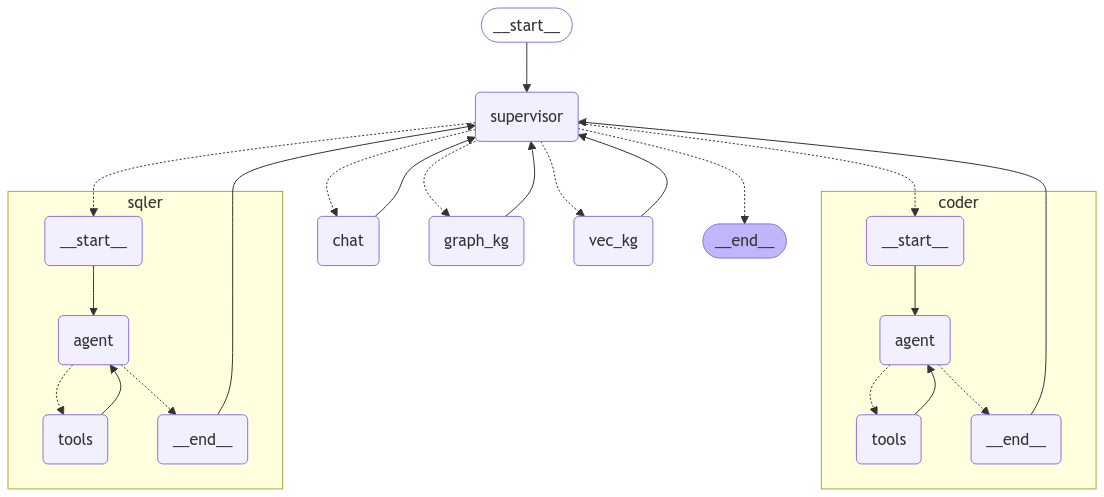

In [158]:
display_graph(graph, xray=True)


&emsp;&emsp;编译完成后，就可以进行问答了，这里我们测试几轮不同的问题类型：

In [159]:
for chunk in graph.stream({"messages": "都有哪些公司在我的数据库中。"}, stream_mode="values"):
    chunk["messages"][-1].pretty_print()

================================ Human Message =================================

都有哪些公司在我的数据库中。
================================ Human Message =================================

都有哪些公司在我的数据库中。
================================ Human Message =================================
Name: graph_kg

在您的数据库中，有以下公司：小米科技有限责任公司、小米基金会、Adobe、微软、华为技术有限公司、剑桥大学、苹果公司、英特尔和谷歌。
================================ Human Message =================================
Name: graph_kg

在您的数据库中，有以下公司：小米科技有限责任公司、小米基金会、Adobe、微软、华为技术有限公司、剑桥大学、苹果公司、英特尔和谷歌。
================================ Human Message =================================
Name: vec_kg

在您的数据库中，确实存在华为技术有限公司。根据提供的上下文，华为在全球设有20多个研发中心，专注于通信技术的创新，尤其是在5G、云计算、大数据和人工智能方面。
================================ Human Message =================================
Name: vec_kg

在您的数据库中，确实存在华为技术有限公司。根据提供的上下文，华为在全球设有20多个研发中心，专注于通信技术的创新，尤其是在5G、云计算、大数据和人工智能方面。
